# Honey Production Analysis

## 1. Import libraries

In [1]:
# Standard library
from pathlib import Path
import shutil

# Third-party libraries
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import linear_model

## 2. Retrieve Dataset

In [2]:
# Define dataset and local data directory
dataset = "jessicali9530/honey-production"
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Download the dataset
download_path = Path(kagglehub.dataset_download(dataset))

# Copy CSV files to the local data directory
for file in download_path.glob("*.csv"):
    shutil.copy2(file, data_dir / file.name)

print(f"Dataset stored in: {data_dir.resolve()}")

Dataset stored in: C:\Users\Cloud\Documents\Projects\honey-production\data


## 3. Load dataset

In [3]:
df = pd.read_csv(data_dir / "honeyproduction.csv")

display(df.head())

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


## 4. Prepare the Data

In [4]:
prod_per_year = df.groupby('year').totalprod.mean().reset_index()

display(prod_per_year.head())

,year,totalprod
0,1998,5.105093e+06
1,1999,4.706674e+06
2,2000,5.106000e+06
3,2001,4.221545e+06
4,2002,3.892386e+06


## 5. Define the Features and Target

In [5]:
X = prod_per_year['year'].values.reshape(-1, 1)
y = prod_per_year['totalprod'].values

## 6. Train the Linear Regression Model

In [6]:
regr = linear_model.LinearRegression()
regr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-88303.19]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.812e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[16.73]


## 7. Analyse the Regression

In [7]:
print(f"Coefficients: {regr.coef_}")
print(f"Intercept: {regr.intercept_}")

y_predict = regr.predict(X)


Coefficients: [-88303.18915238]
Intercept: 181208083.1073298


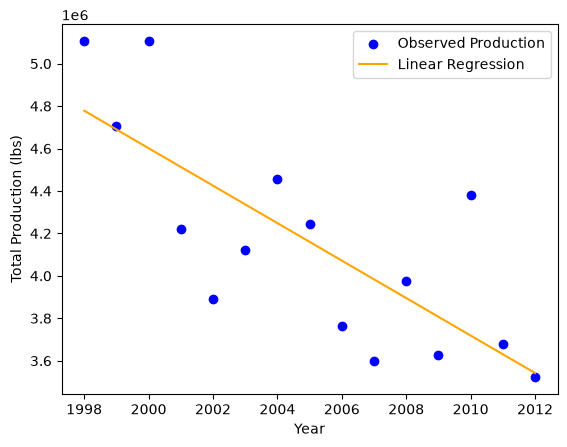

In [8]:
plt.figure(1)

plt.scatter(X, y, color='blue', label="Observed Production")
plt.plot(X, y_predict, color='orange', label="Linear Regression")

plt.ylabel("Total Production (lbs)")
plt.xlabel("Year")
plt.legend()

plt.show()

## 8. Predict Future Honey Production

In [9]:
X_future = np.array(range(2013, 2051)).reshape(-1, 1)

future_predict = regr.predict(X_future)

## 9. Visualise Future Predictions

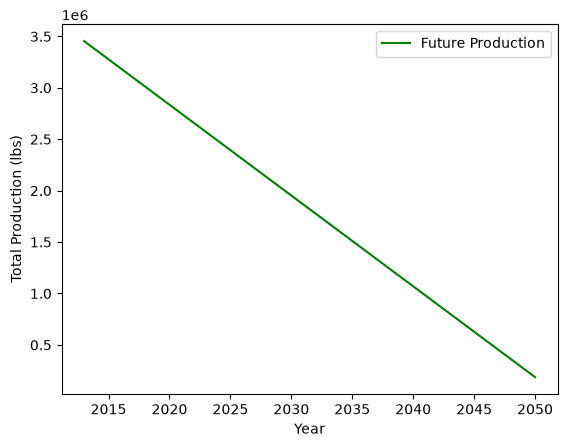

In [10]:
plt.figure(2)

plt.plot(X_future, future_predict, color='green', label="Future Production")

plt.ylabel("Total Production (lbs)")
plt.xlabel("Year")
plt.legend()

plt.show()

How much honey will be produced in the year 2050?

In [11]:
print(f"Predicted honey production (lbs) in 2050: {future_predict[-1]:,.0f}")

Predicted honey production (lbs) in 2050: 186,545


## Conclusion

The linear regression analysis identified a negative relationship between year and honey production over the historical period represented in the dataset. The fitted regression line therefore indicates that honey production tended to decrease as year increased.

When the fitted linear trend was extrapolated to 2050, the model estimated honey production of approximately 186,545 lbs.

This value should not be interpreted as a reliable forecast of honey production in 2050. The model uses year as its only explanatory variable and assumes that the historical linear relationship continues beyond the observed 1998–2012 data.